In [21]:
# load libraries
import pandas as pd
import numpy as np
# train test split
from sklearn.model_selection import train_test_split
# GridSearchCV - hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost
# metrics
from sklearn.metrics import accuracy_score, log_loss, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
# data visualization
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import shap


In [22]:
# Setting random seed for reproducibility
np.random.seed(42)

Import Data

In [23]:
df_raw_data = pd.read_csv('../02_src/uci_diabetes.csv')
df_raw_data.head()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [24]:
# filtering by gender - female
df = df_raw_data.loc[df_raw_data['Gender'] == 'Male']

Data Cleaning

In [25]:
# Gender column is not needed since all members are the same and we are not including gender as a predictor
df = df.drop(columns=['Gender'])

# Binary encoding
binary_map = {"Yes": 1, "No": 0}
#gender_map = {"Male": 0, "Female": 1}
class_map = {"Negative": 0, "Positive": 1}

# dropping demographic data and class (y variable)
symptom_cols = df.columns.drop(["Age", "class"])

df[symptom_cols] = df[symptom_cols].replace(binary_map)
#df["Gender"] = df["Gender"].replace(gender_map)
df["class"] = df["class"].replace(class_map)


C:\Users\shafe\AppData\Local\Temp\ipykernel_36972\4158227504.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[symptom_cols] = df[symptom_cols].replace(binary_map)
C:\Users\shafe\AppData\Local\Temp\ipykernel_36972\4158227504.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["class"] = df["class"].replace(class_map)


In [26]:

df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0,30,45,60,100],
                        labels=['<30','30–44','45–59','60+'])

# for these algorithms, we will not need the Age as an int
df = df.drop(columns=['Age'])

In [27]:
# Perform one-hot encoding on the 'AgeGroup' column
#  drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=['AgeGroup'], prefix='AgeGroup',  drop_first=True)

print(df_encoded.columns)

Index(['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
       'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
       'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class', 'AgeGroup_30–44',
       'AgeGroup_45–59', 'AgeGroup_60+'],
      dtype='object')


In [28]:
# target (y) dataset
target = df['class']
target

0      1
1      1
2      1
3      1
4      1
      ..
509    0
510    0
511    0
512    0
519    0
Name: class, Length: 328, dtype: int64

In [29]:
# predictors dataset
df_data = df_encoded.drop(columns=['class'])
df_data

,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,AgeGroup_30–44,AgeGroup_45–59,AgeGroup_60+
0,0,1,0,1,0,0,0,1,0,1,0,1,1,1,True,False,False
1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,False,True,False
2,1,0,0,1,1,0,0,1,0,1,0,1,1,0,True,False,False
3,0,0,1,1,1,1,0,1,0,1,0,0,0,0,True,False,False
4,1,1,1,1,1,0,1,1,1,1,1,1,1,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,0,0,0,0,0,0,0,0,0,0,0,0,0,0,False,True,False
510,0,0,0,1,0,0,0,1,0,1,0,0,1,0,False,False,True
511,0,0,0,1,1,0,1,1,0,1,1,1,1,0,False,False,True
512,0,0,0,0,0,0,0,0,0,0,0,0,1,0,True,False,False


X and Y

In [30]:
X = df_data
y = target

In [31]:
# Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle= True, stratify = y,
) #

Subrotine that will be reused for evaluation

In [32]:
# subroutine for evaluation
def evaluation(model, X_test, y_test):
    # testing
    y_pred = model.predict(X_test)

    print(classification_report(y_pred, y_test))

    # Evaluation
    # Get the default accuracy score
    accuracy = model.score(X_test, y_test)
    print(f"Accuracy Score: {accuracy}")

    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=model.classes_)
    disp.plot()
    plt.show()

    # Calculate the log loss
    y_pred_proba = model.predict_proba(X_test)
    loss = log_loss(y_test, y_pred_proba)

    print(f"Log Loss: {loss}")

Testing with Logistic Regression

              precision    recall  f1-score   support

           0       0.97      0.90      0.93        39
           1       0.87      0.96      0.91        27

    accuracy                           0.92        66
   macro avg       0.92      0.93      0.92        66
weighted avg       0.93      0.92      0.92        66

Accuracy Score: 0.9242424242424242


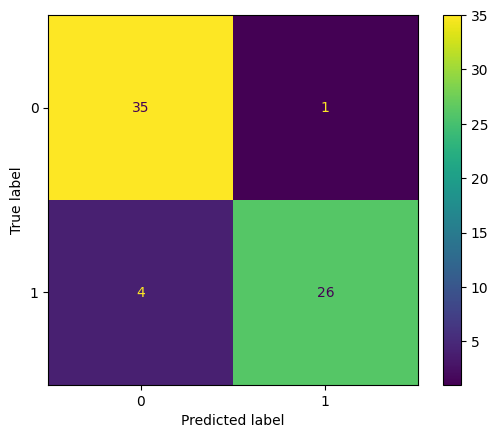

Log Loss: 0.21922003691460537


In [33]:
# Initialize
model = LogisticRegression()
# Train Model
model.fit(X_train, y_train) 

# Evaluation
evaluation(model, X_test, y_test)

Decision Tree Classifier

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.93      1.00      0.97        28

    accuracy                           0.97        66
   macro avg       0.97      0.97      0.97        66
weighted avg       0.97      0.97      0.97        66

Accuracy Score: 0.9696969696969697


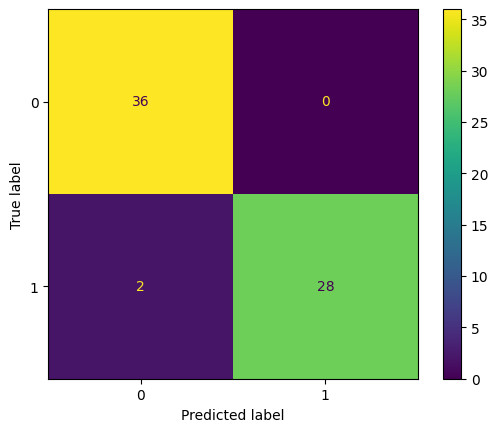

Log Loss: 1.092231920882338


In [34]:
# Initialize
model_dtc = DecisionTreeClassifier()
# Train model
model_dtc.fit(X_train, y_train)

# Evaluation
evaluation(model_dtc, X_test, y_test)


Random Forest Classifier

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.97      1.00      0.98        29

    accuracy                           0.98        66
   macro avg       0.98      0.99      0.98        66
weighted avg       0.99      0.98      0.98        66

Accuracy Score: 0.9848484848484849


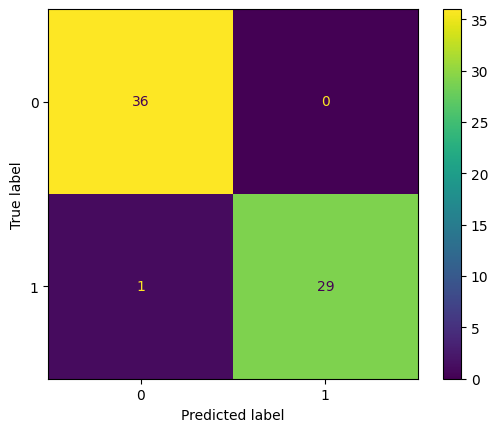

Log Loss: 0.06680167866913338


In [35]:
# Initialize the Random Forest Classifier
model_rfc = RandomForestClassifier(n_estimators=100)

# Train the model
model_rfc.fit(X_train, y_train)

# Evaluation
evaluation(model_rfc, X_test, y_test)

Log loss report seems most promising for decision tree classifier so will perform hyperparameter tuning and further evaluation with random forest algorithm

In [36]:
# source https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

# mplement a grid search using GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=10)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Estimator: RandomForestClassifier(n_estimators=200)


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.97      1.00      0.98        29

    accuracy                           0.98        66
   macro avg       0.98      0.99      0.98        66
weighted avg       0.99      0.98      0.98        66

Accuracy Score: 0.9848484848484849


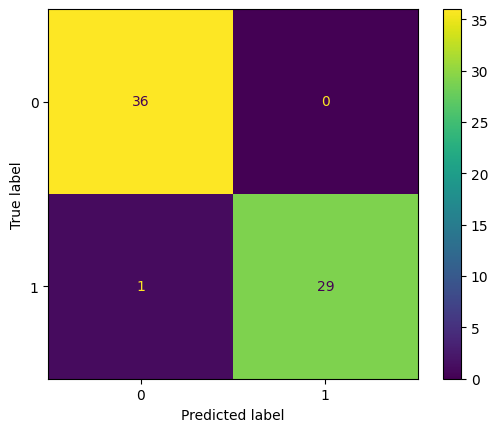

Log Loss: 0.07843536884391508


In [37]:
model_grid = RandomForestClassifier()
model_grid.fit(X_train, y_train)

# Evaluation
evaluation(model_grid, X_test, y_test)

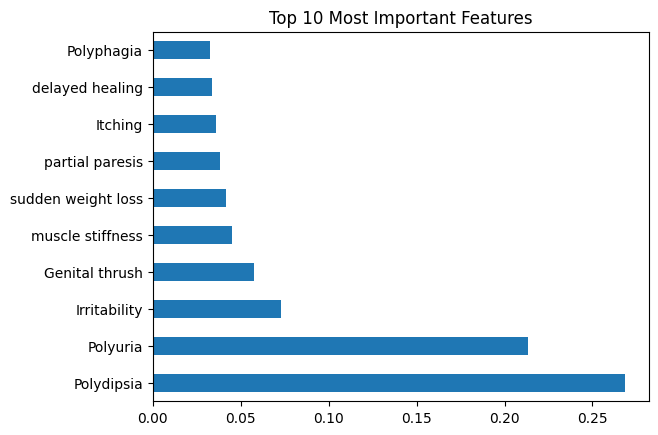

In [38]:
# Create a Series with feature importances
importances = pd.Series(model_grid.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

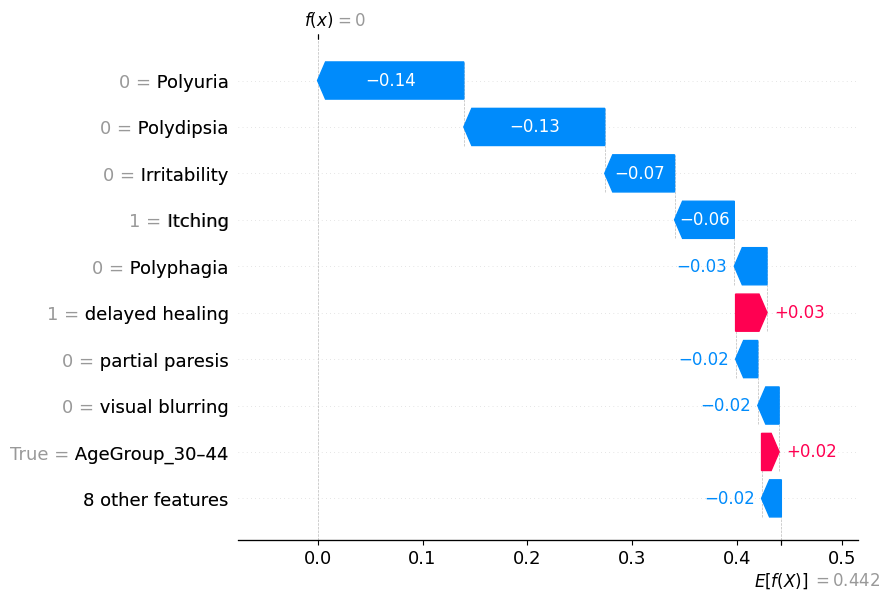

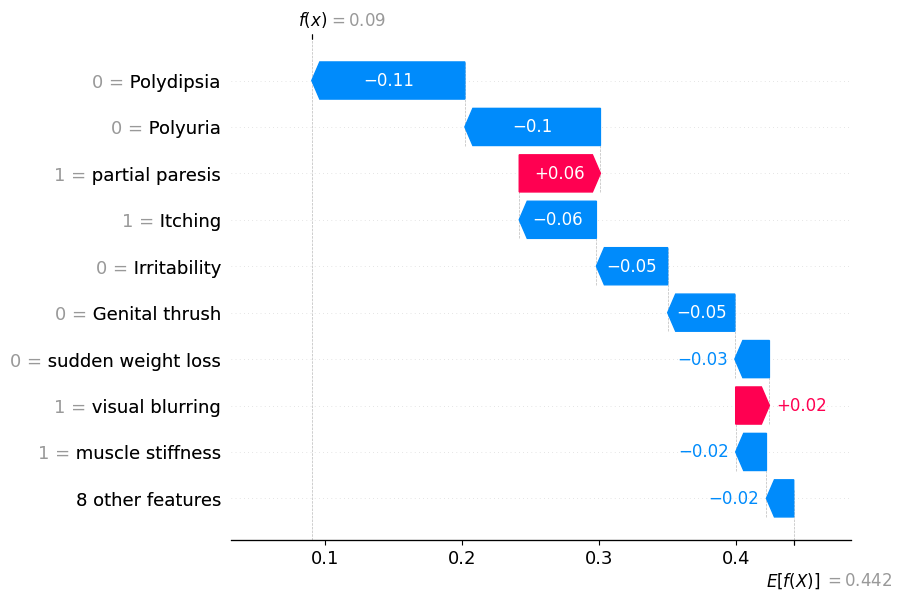

In [39]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_grid)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_36972\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


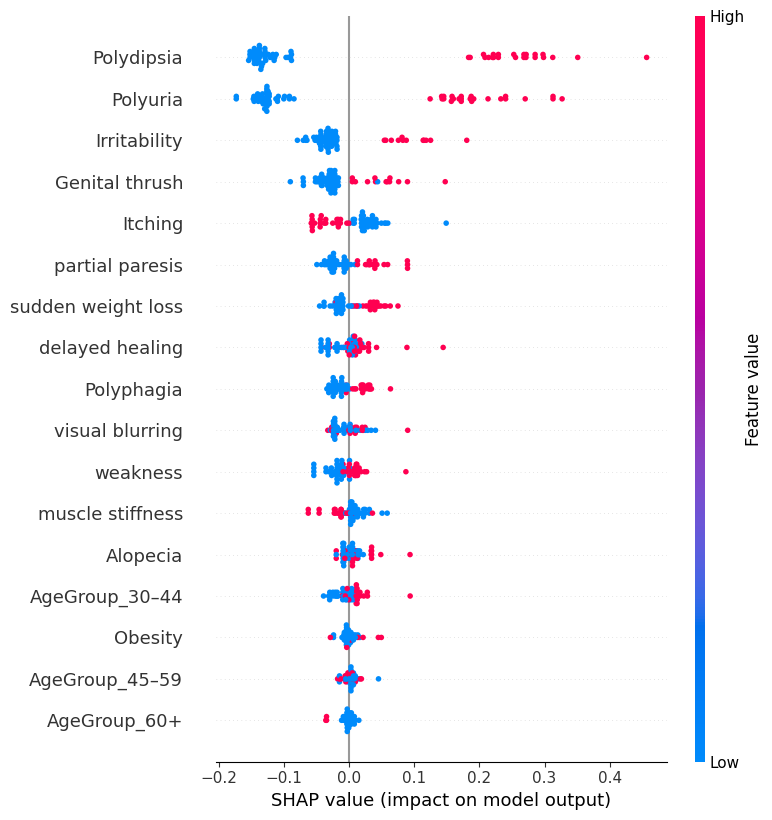

In [40]:
shap.summary_plot(shap_values[:, :, 1], X_test)

              precision    recall  f1-score   support

           0       1.00      0.95      0.97        38
           1       0.93      1.00      0.97        28

    accuracy                           0.97        66
   macro avg       0.97      0.97      0.97        66
weighted avg       0.97      0.97      0.97        66

Accuracy Score: 0.9696969696969697


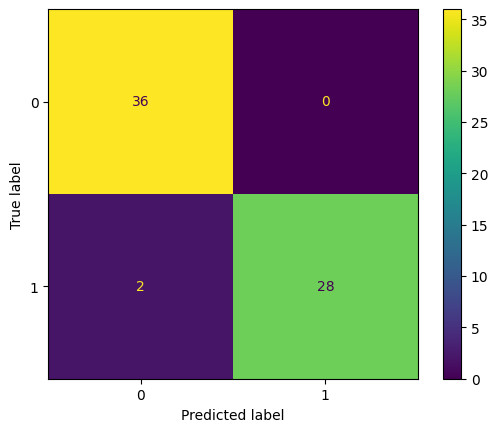

Log Loss: 0.06150185161153231


In [41]:
# Train a model
model_xgb = xgboost.XGBClassifier()
model_xgb.fit(X_train, y_train)
evaluation(model_xgb, X_test, y_test)

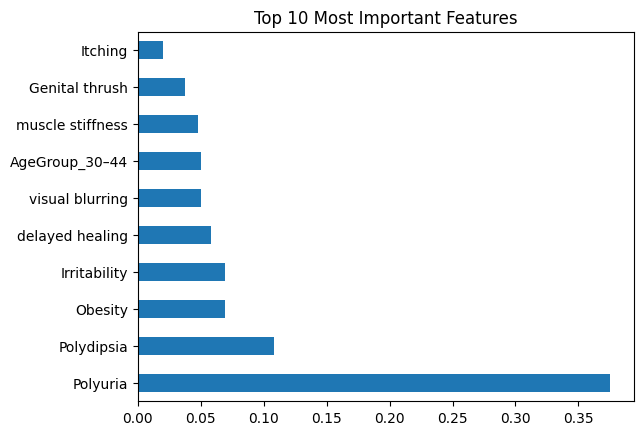

In [42]:
# Create a Series with feature importances
importances = pd.Series(model_xgb.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh') # top 10
plt.title("Top 10 Most Important Features")
plt.show()

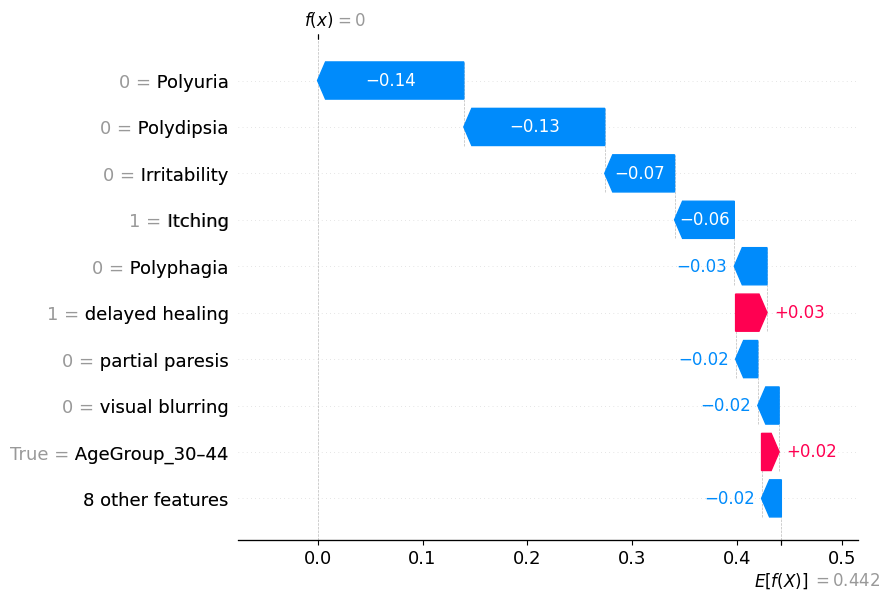

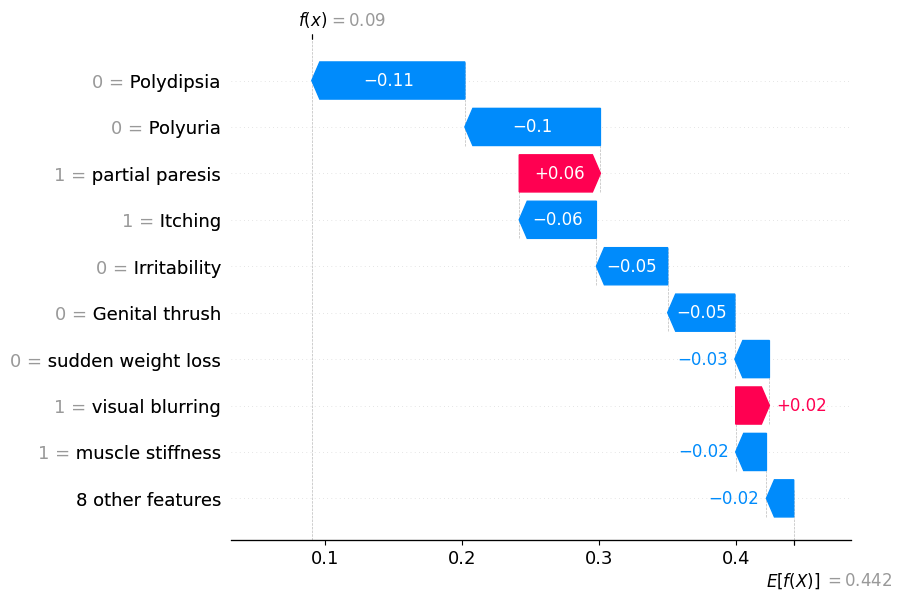

In [43]:
# SHAP
# TreeExplainer is highly optimized for Random Forests
explainer = shap.TreeExplainer(model_grid)
shap_values = explainer(X_test) # Calculate SHAP values for the test set

# Local Explanation: Waterfall Plot
# Shows why the model made a specific prediction (e.g., for the first test row)
# Note: For classification, we specify index [:, :, 1] for the 'Positive' class
shap.plots.waterfall(shap_values[0, :, 1])
shap.plots.waterfall(shap_values[1, :, 1])

C:\Users\shafe\AppData\Local\Temp\ipykernel_36972\2344957999.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test)


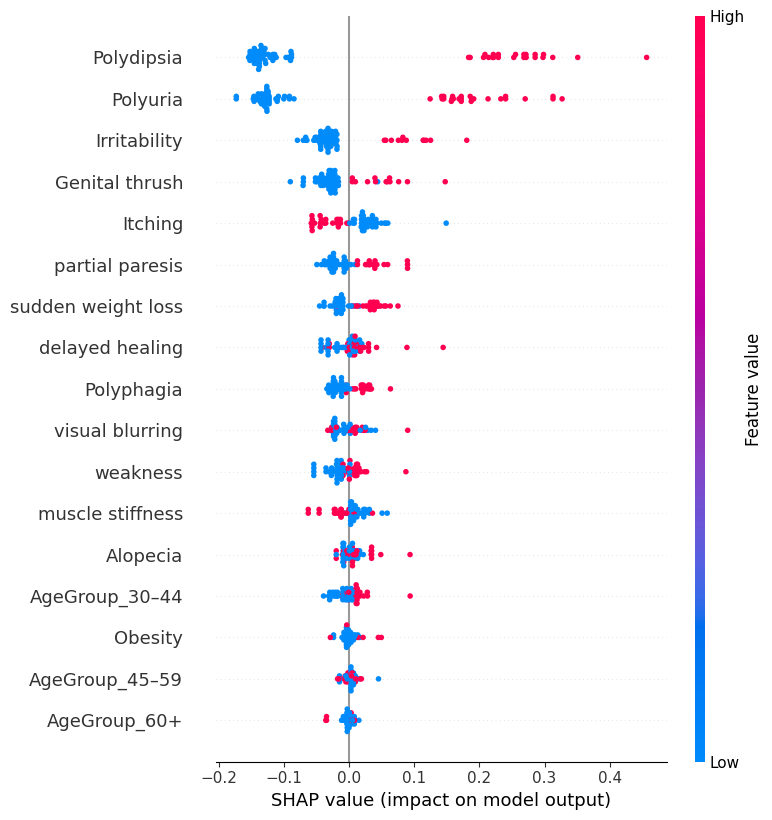

In [44]:
shap.summary_plot(shap_values[:, :, 1], X_test)